# Basic Report Generation

This notebook will provide a basic overview of how to generate some simple reports using `NOCAT` (name pending).

In [1]:
import xarray as xr
from pathlib import Path
import os

cwd = os.getcwd()
os.chdir(f"{cwd}/../../src")
from toolbox.pipeline import *

[Discovery] Scanning for step modules in /home/aaron-mau/Code/NOC-toolbox/mau/toolbox/src/toolbox/steps/custom
[Discovery] Importing step module: toolbox.steps.custom.blank_step
[Discovery] Importing step module: toolbox.steps.custom.load_data
[Discovery] Importing step module: toolbox.steps.custom.gen_data
[Discovery] Importing step module: toolbox.steps.custom.find_profiles
[Discovery] Importing step module: toolbox.steps.custom.interpolate_data
[Discovery] Importing step module: toolbox.steps.custom.derive_ctd
[Discovery] Importing step module: toolbox.steps.custom.profile_direction
[Discovery] Importing step module: toolbox.steps.custom.apply_qc
[Discovery] Importing step module: toolbox.steps.custom.write_report
[Discovery] Importing step module: toolbox.steps.custom.export
[Discovery] Importing step module: toolbox.steps.custom.variables.chla
[Discovery] Importing step module: toolbox.steps.custom.variables.bbp
[Discovery] Importing step module: toolbox.steps.custom.variables.oxy

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


For this example, we'll use the Nelson example as found in other notebooks.

In [2]:
input_dir = Path("../data/OG1")
input_file = input_dir / "Nelson_646_R.nc"
if not input_dir.exists():
    input_dir.mkdir(parents=True)
if not input_file.exists():
    import requests
    response = requests.get("https://linkedsystems.uk/erddap/files/Public_OG1_Data_001/Nelson_20240528/Nelson_646_R.nc")
    if response.status_code == 200:
        with open(input_file, "wb") as f:
            f.write(response.content)
        print(f"Example file downloaded and written to {input_dir.resolve()}")
    else:
        print("File download failed")
dataset = xr.load_dataset("../data/OG1/Nelson_646_R.nc")
dataset

<xarray.Dataset> Size: 443MB
Dimensions:                               (N_MEASUREMENTS: 2014856, N_PARAM: 24)
Dimensions without coordinates: N_MEASUREMENTS, N_PARAM
Data variables: (12/68)
    TIME                                  (N_MEASUREMENTS) datetime64[ns] 16MB ...
    TIME_GPS                              (N_MEASUREMENTS) datetime64[ns] 16MB ...
    PHASE                                 (N_MEASUREMENTS) float32 8MB nan .....
    PHASE_QC                              (N_MEASUREMENTS) float32 8MB nan .....
    CNDC                                  (N_MEASUREMENTS) float32 8MB 0.0 .....
    PRES                                  (N_MEASUREMENTS) float32 8MB 0.0 .....
    ...                                    ...
    PLATFORM_TYPE                         <U6 24B 'slocum'
    PLATFORM_MODEL                        <U2 8B 'G2'
    WMO_IDENTIFIER                        <U3 12B '830'
    DEPLOYMENT_TIME                       datetime64[ns] 8B 2024-05-27T23:00:00
    DEPLOYMENT_LATITUDE                   <U17 68B '50.89280319213867'
    DEPLOYMENT_LONGITUDE                  <U19 76B '-1.3955066204071045'
Attributes: (12/68)
    geospatial_bounds_crs:           EPSG:4326
    geospatial_bounds_vertical_crs:  EPSG:5831
    geospatial_lat_min:              50.890984
    geospatial_lat_max:              62.482586
    geospatial_lon_min:              50.890984
    geospatial_lon_max:              62.482586
    ...                              ...
    instrument:                      ['SBE Slocum Glider Payload (GPCTD) CTD'...
    metadata_link:                   https://api.linked-systems.uk/api/meta/v...
    trajectory:                      Nelson_20240528
    date_created:                    2024-09-30T08:14:20.465997
    date_modified:                   2024-09-30T08:14:20.466021
    id:                              Nelson_20240528T000000_R

Now build our pipeline of steps. Let's use an example configuration made by Voice of the Ocean in Sweden. This configuration uses a series of four steps:
1. Load OG1 data
2. Apply quality control
3. Export the data
4. Write the report

VOTO uses gliders with different measured parameters and settings, so rather than rewrite the file, we'll tweak the settings of the `Apply QC` step.

In [3]:
#   Building the Pipe object of various steps
Pipe = Pipeline(config_path = r"../examples/configs/voto_config.yaml")

2026-03-03 13:58:00 - INFO - toolbox.pipeline - Logging to file: /home/aaron-mau/Code/NOC-toolbox/mau/toolbox/examples/data/OG1/testing/voto_processing.log
2026-03-03 13:58:00 - INFO - toolbox.pipeline - Assembling steps to run from config.
2026-03-03 13:58:00 - INFO - toolbox.pipeline - Step 'Load OG1' added successfully!
2026-03-03 13:58:00 - INFO - toolbox.pipeline - Step 'Apply QC' added successfully!
2026-03-03 13:58:00 - INFO - toolbox.pipeline - Step 'Data Export' added successfully!
2026-03-03 13:58:00 - INFO - toolbox.pipeline - Step 'Write Data Report' added successfully!
2026-03-03 13:58:00 - INFO - toolbox.pipeline - Pipeline initialised


In [4]:
for i, step in enumerate(Pipe.steps):
    print(f"{i} {step["name"]}, \t {list(step["parameters"].keys())}")
    print(f"\t\t {list(step["parameters"].items())}")

0 Load OG1, 	 ['file_path']
		 [('file_path', '../examples/data/OG1/sea055_20240628T0856_delayed.nc')]
1 Apply QC, 	 ['qc_settings']
		 [('qc_settings', {'impossible date test': {}, 'impossible location test': {}, 'position on land test': {}, 'impossible speed test': {}, 'range test': {'variable_ranges': {'PRES': {3: [-5, -2.4], 4: [-inf, -5]}}, 'also_flag': {'PRES': ['CNDC', 'TEMP']}, 'plot': ['PRES']}, 'gross range test': {'variable_ranges': {'TEMP': {3: [0, 30], 4: [-2.5, 40]}, 'CNDC': {3: [5, 42], 4: [2, 45]}, 'DOXY': {3: [0.01, 425], 4: [0, 500]}, 'CHLA': {3: [0, 15], 4: [-1, 20]}}, 'also_flag': {'PRES': ['TEMP', 'CNDC', 'DOXY'], 'TEMP': ['CNDC', 'DOXY'], 'CNDC': ['DOXY']}}, 'spike test': {'variables': {'PRES': 5.0}, 'also_flag': {'CNDC': ['PSAL']}, 'window_size': 10, 'plot': ['PRES', 'TEMP', 'CNDC']}, 'stuck value test': {'variables': {'PRES': 2}, 'also_flag': {'PRES': ['CNDC', 'TEMP']}, 'plot': ['PRES']}})]
2 Data Export, 	 ['export_format', 'output_path']
		 [('export_format', 

In [ ]:
Pipe.steps[0]["parameters"]["file_path"] = '../examples/data/OG1/Nelson_646_R.nc'   #   Change the name of our read-in file
del Pipe.steps[1]["parameters"]["qc_settings"]["spike test"]                        #   Remove steps with missing variables
del Pipe.steps[1]["parameters"]["qc_settings"]["gross range test"]["variable_ranges"]["DOXY"]
del Pipe.steps[1]["parameters"]["qc_settings"]["gross range test"]["also_flag"]
Pipe.steps[2]["parameters"]["output_path"] = "../examples/data/OG1/demo.nc"
Pipe.steps[3]["parameters"]["title"] = "Report Demo"
Pipe.steps[3]["parameters"]["fname"] = "demo.rst"
Pipe.steps[3]["parameters"]["extent"] = [5, -35, 45, 70]  #   This example is closer to Iceland. Wrap the inset figure around the data domain.

In [6]:
for i, step in enumerate(Pipe.steps):
    print(f"{i} {step["name"]}, \t {list(step["parameters"].keys())}")
    print(f"\t\t {list(step["parameters"].items())}")

0 Load OG1, 	 ['file_path']
		 [('file_path', '../examples/data/OG1/Nelson_646_R.nc')]
1 Apply QC, 	 ['qc_settings']
		 [('qc_settings', {'impossible date test': {}, 'impossible location test': {}, 'position on land test': {}, 'impossible speed test': {}, 'range test': {'variable_ranges': {'PRES': {3: [-5, -2.4], 4: [-inf, -5]}}, 'also_flag': {'PRES': ['CNDC', 'TEMP']}, 'plot': ['PRES']}, 'gross range test': {'variable_ranges': {'TEMP': {3: [0, 30], 4: [-2.5, 40]}, 'CNDC': {3: [5, 42], 4: [2, 45]}, 'CHLA': {3: [0, 15], 4: [-1, 20]}}}, 'stuck value test': {'variables': {'PRES': 2}, 'also_flag': {'PRES': ['CNDC', 'TEMP']}, 'plot': ['PRES']}})]
2 Data Export, 	 ['export_format', 'output_path']
		 [('export_format', 'netcdf'), ('output_path', '../examples/data/OG1/demo.nc')]
3 Write Data Report, 	 ['title', 'fname', 'build', 'extent']
		 [('title', 'Report Demo'), ('fname', 'demo.rst'), ('build', True), ('extent', [5, -35, 45, 70])]


So now we've tweaked the pipeline to correctly run through. Now we can start the run.

2026-03-03 13:58:00 - INFO - toolbox.pipeline - Executing: Load OG1
2026-03-03 13:58:00 - INFO - toolbox.pipeline.step.Load OG1 - [Load OG1] Loaded data from ../examples/data/OG1/Nelson_646_R.nc
2026-03-03 13:58:00 - INFO - toolbox.pipeline - Executing: Apply QC
2026-03-03 13:58:00 - INFO - toolbox.pipeline.step.Apply QC - [Apply QC] Data found in context.
2026-03-03 13:58:00 - INFO - toolbox.pipeline.step.Apply QC - [Apply QC] Found existing flags columns {'LATITUDE_QC', 'LONGITUDE_QC', 'TEMP_QC', 'CHLA_QC', 'CNDC_QC', 'PRES_QC'} in data.
2026-03-03 13:58:00 - INFO - toolbox.pipeline.step.Apply QC - [Apply QC] Found QC columns for untested values: {'GLIDER_PITCH_QC', 'OXYSAT_DOXY_QC', 'LONGITUDE_GPS_QC', 'RAW_DOWNWELLING_PAR_QC', 'LATITUDE_GPS_QC', 'WATERCURRENTS_V_QC', 'OXYCOPVB_QC', 'TIME_GPS_QC', 'BBP700_QC', 'DOWNWELLING_PAR_QC', 'BPHASE_DOXY_QC', 'BBP532_QC', 'OXYCOPVR_QC', 'ALTITUDE_QC', 'PHASE_QC', 'WATERCURRENTS_U_QC', 'DPHASE_DOXY_QC', 'GLIDER_DEPTH_QC', 'GLIDER_ROLL_QC', 'MO

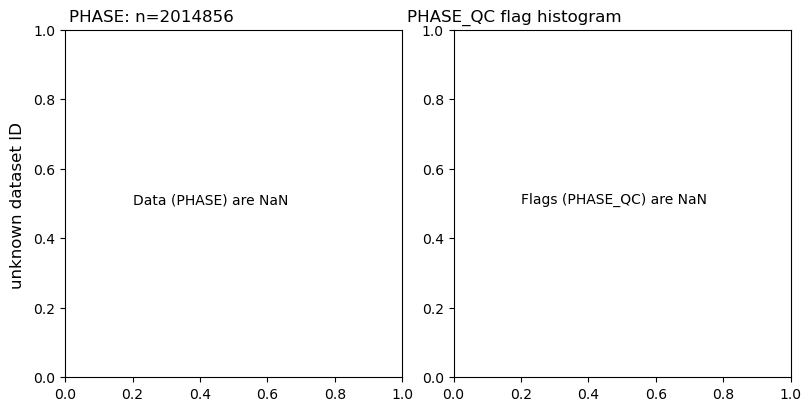

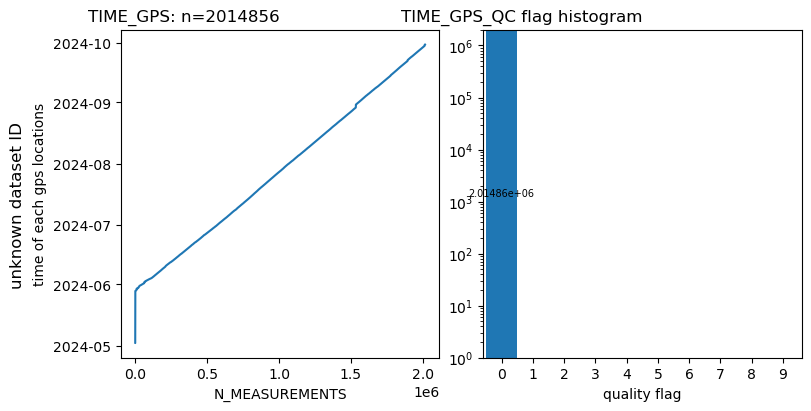

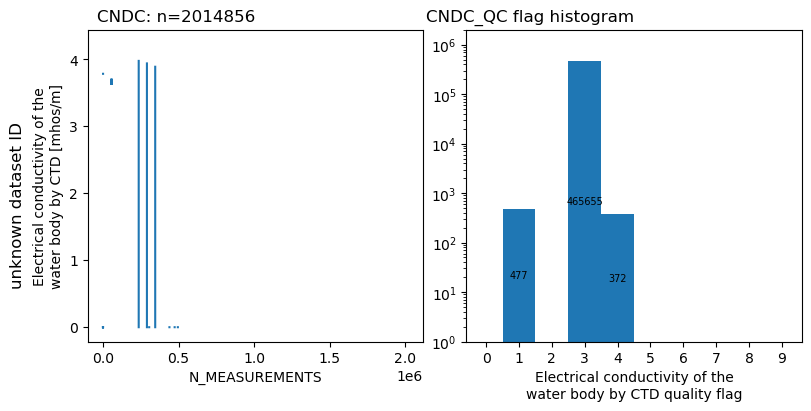

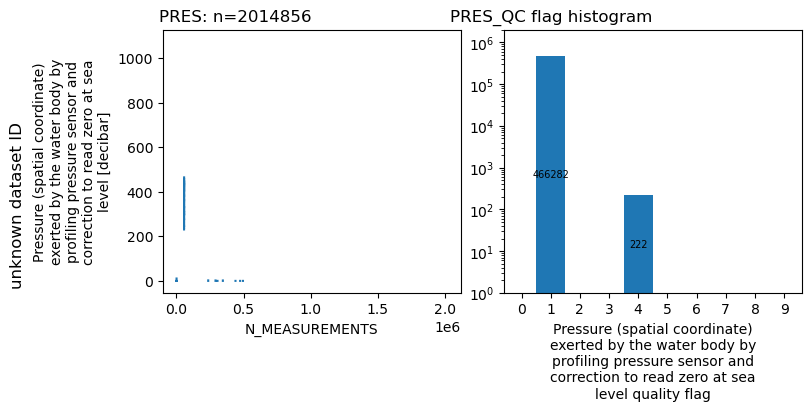

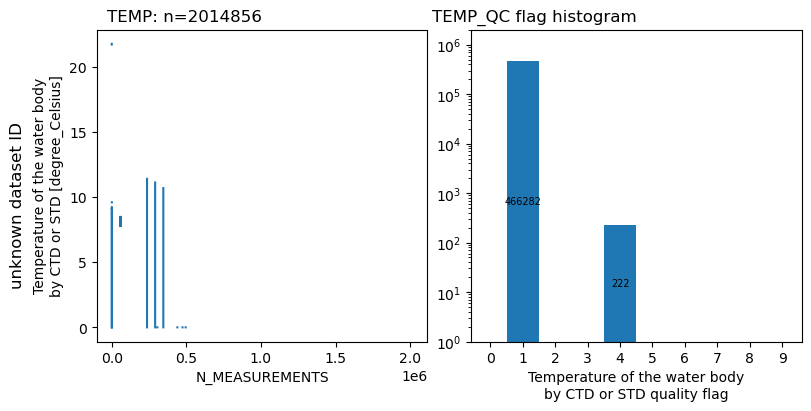

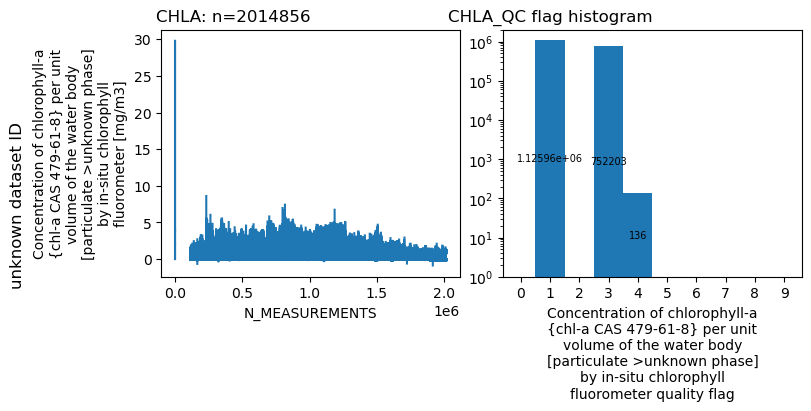

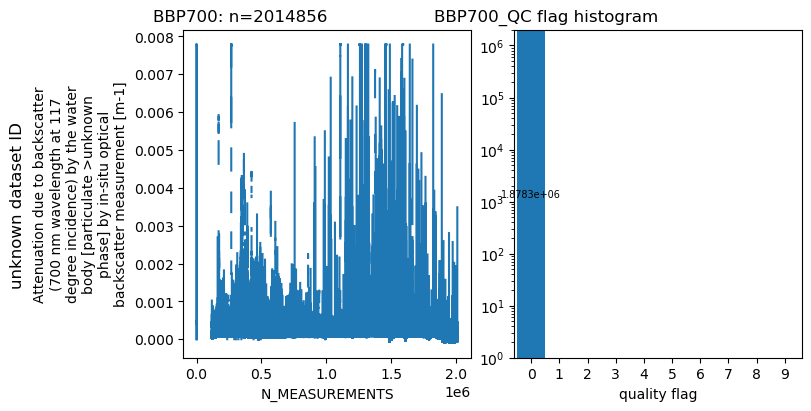

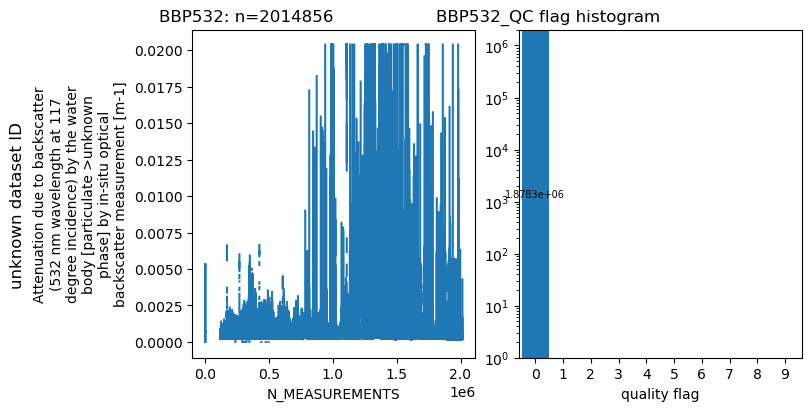

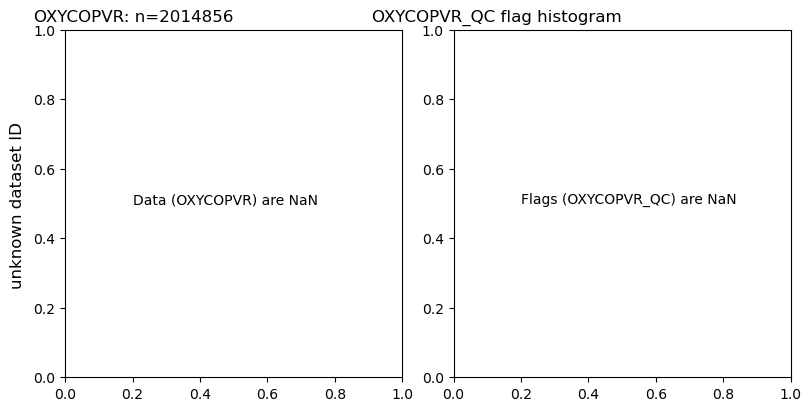

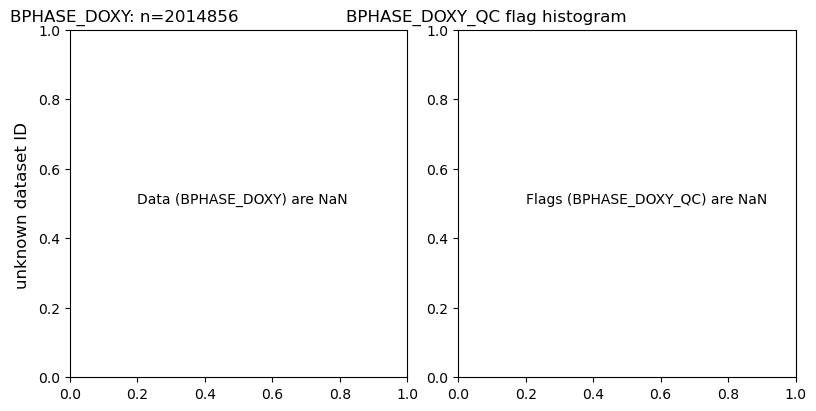

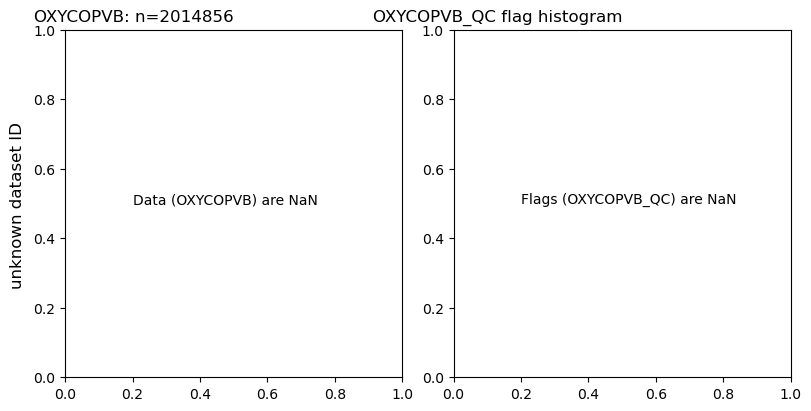

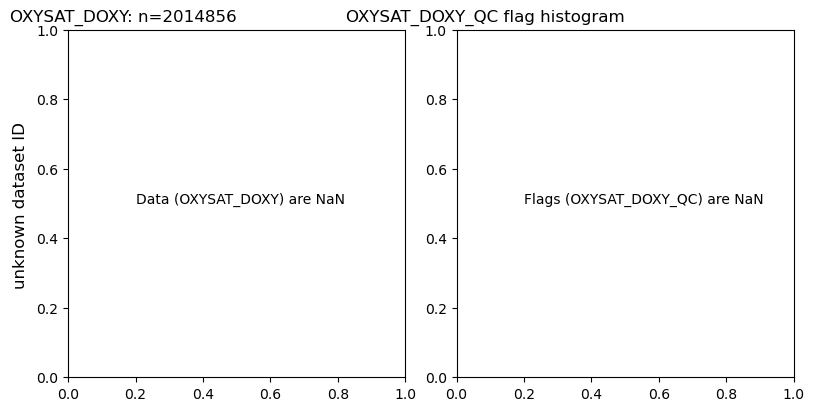

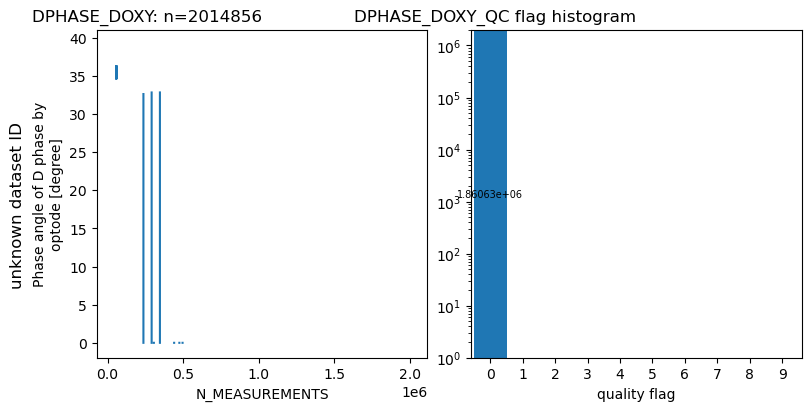

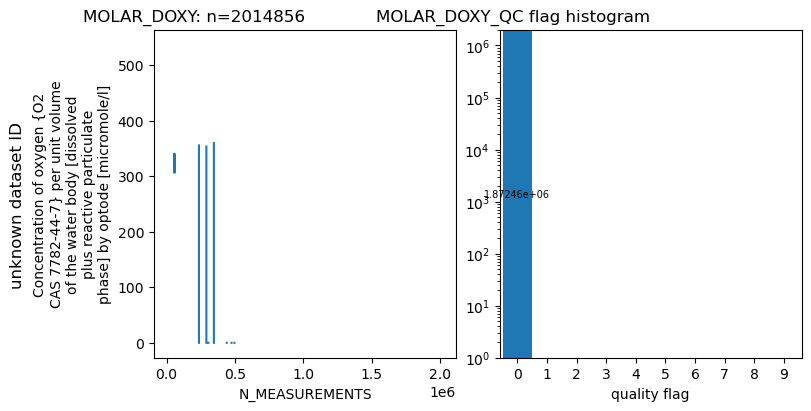

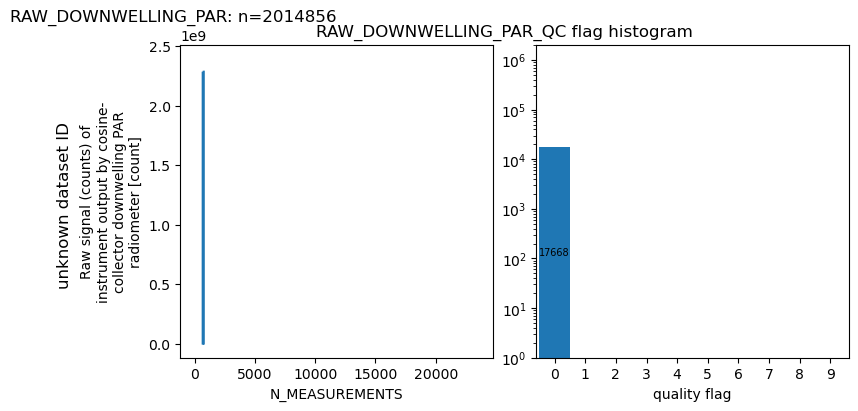

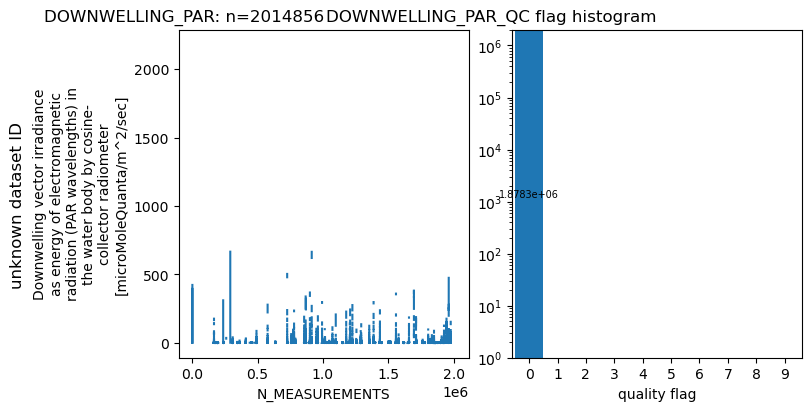

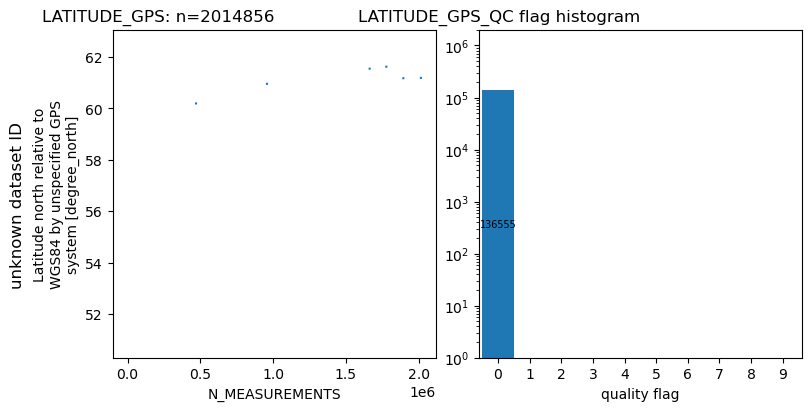

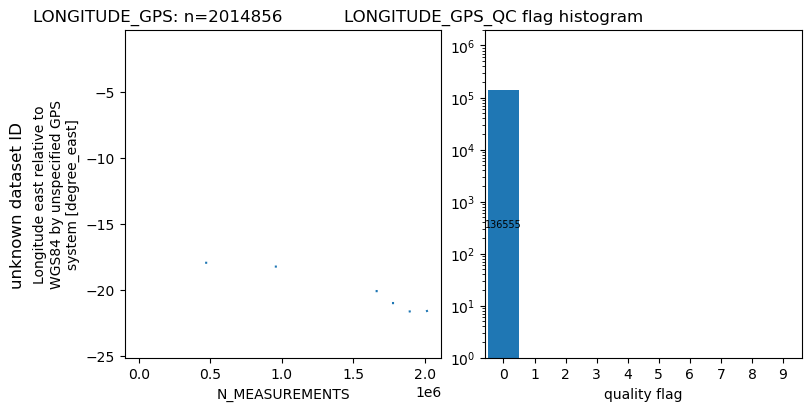

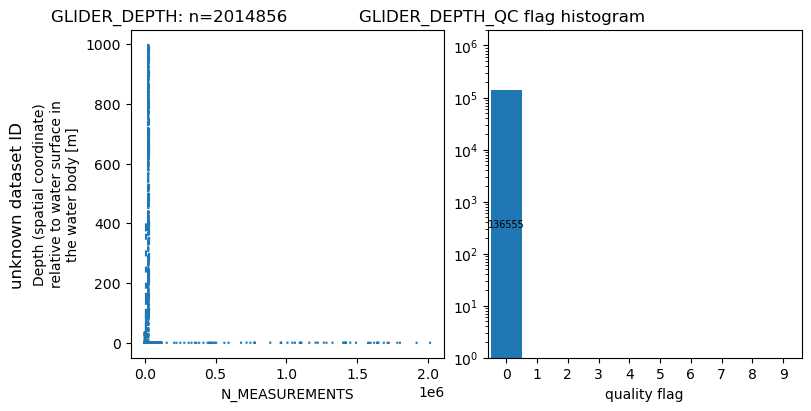

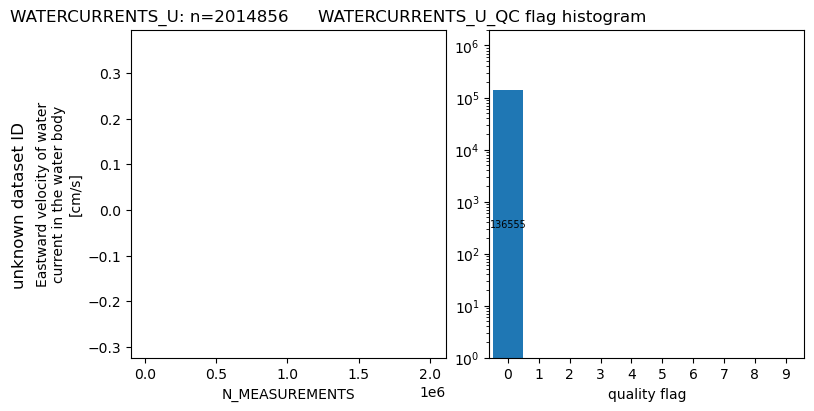

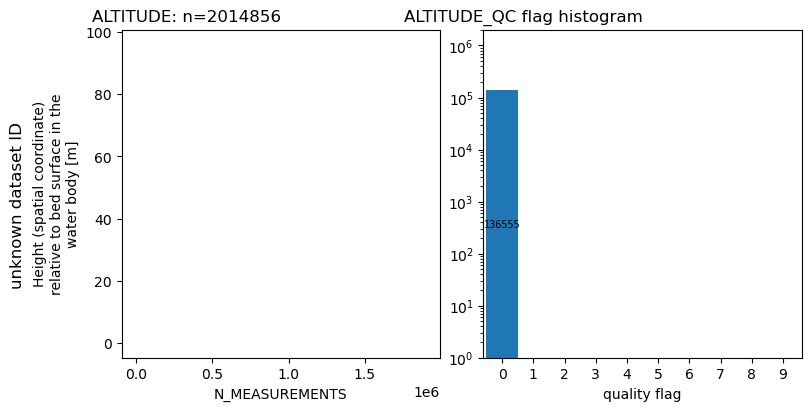

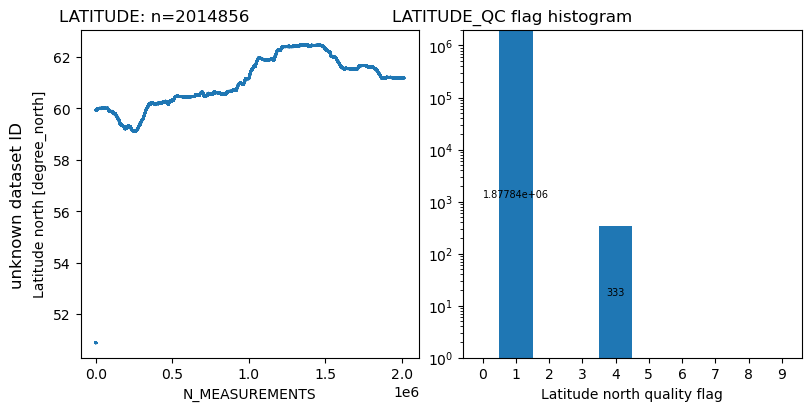

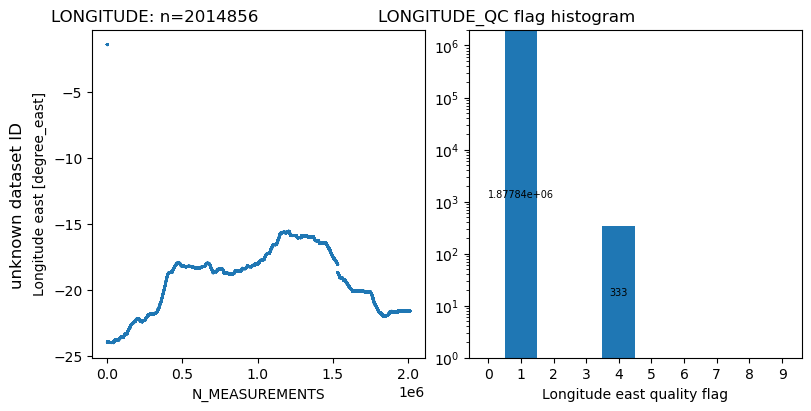

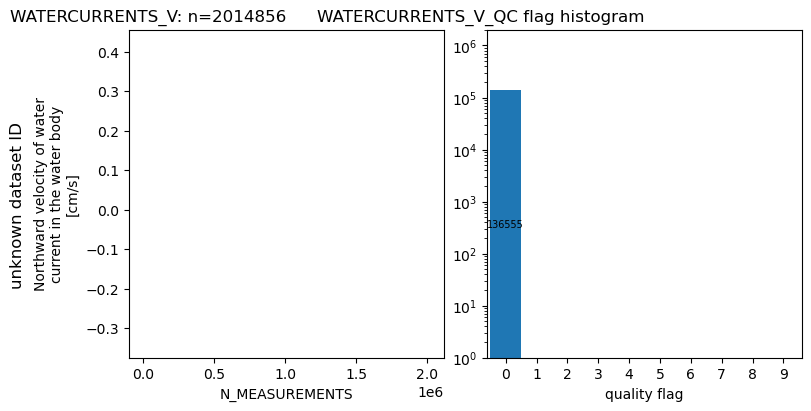

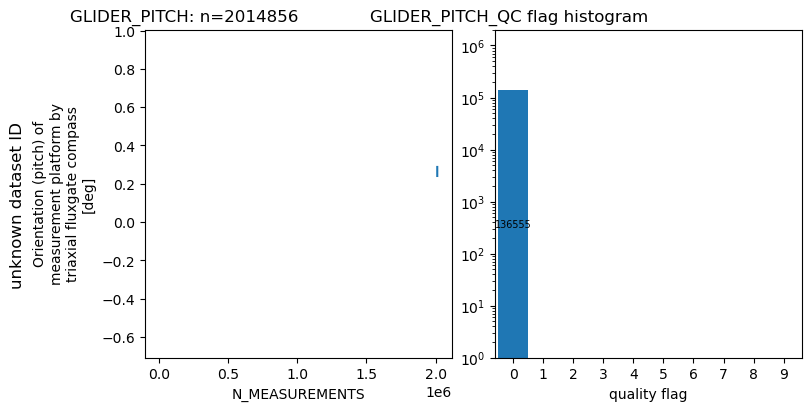

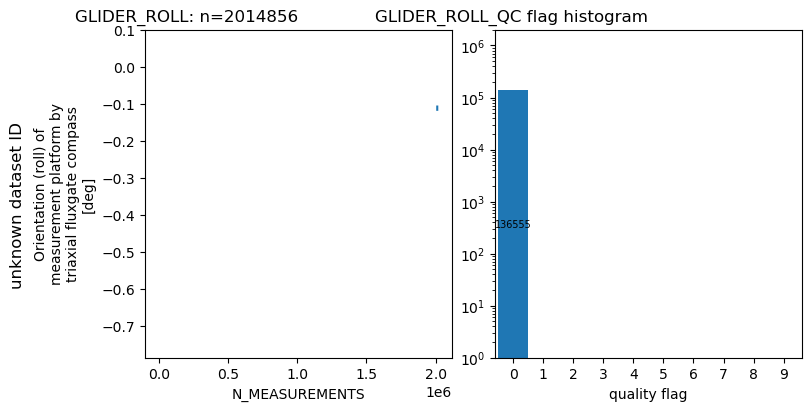

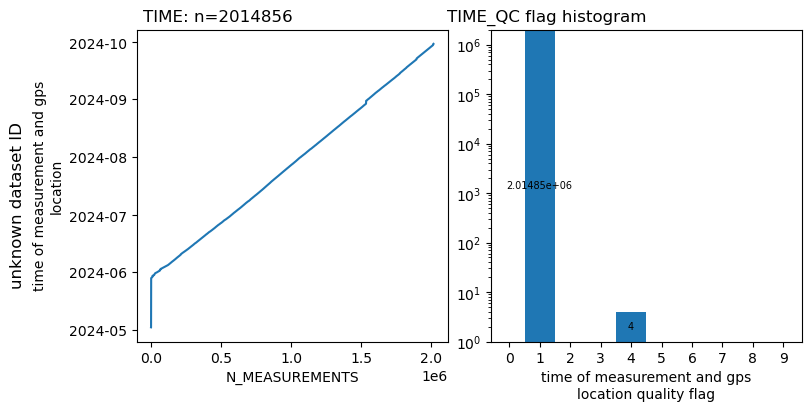

In [7]:
Pipe.run()

The report generation step wrapped up at the very end. Since we didn't change anything related to the pipeline configuration itself, the `out_directory` should still take us to "../examples/data/OG1/testing/".

This has done a number of things. First, we can find all of the information about the run within our logfile - including how long it took to run particular steps. Using the default report template, this logfile is included.

Then it built a `conf.py` and a `demo.rst` file which Sphinx could use to assemble the final PDF.

Next, it has built a series of pictures, including QC results for all the columns with the "_QC" suffix by the end. These QC variables may/may not have been tested. As we can see in the log, the `Apply QC` step "Found QC columns for untested values" and there are a number of columns with QC columns that are not assessed.

Then Sphinx was run and everything was output to "../testing/_build/latex". This is where we can see the final formatted report, including copies of all the individual pieces that went into it.

In [8]:
print(Pipe.pipeline["out_directory"])
print(os.listdir(Pipe.pipeline["out_directory"]))

../examples/data/OG1/testing/
['geographic.png', 'TIME_QC.png', 'BBP700_QC.png', 'WATERCURRENTS_V_QC.png', 'POTDENS0_QC.png', 'DPHASE_DOXY_QC.png', 'RAW_DOWNWELLING_PAR_QC.png', 'BPHASE_DOXY_QC.png', 'CHLA_QC.png', 'LONGITUDE_QC.png', 'TIME_GPS_QC.png', 'TEMP_QC.png', 'OXYCOPVR_QC.png', 'CNDC_QC.png', 'PROFILE_NUMBER_QC.png', 'DOXY_QC.png', 'PSAL_QC.png', 'GLIDER_ROLL_QC.png', 'GLIDER_DEPTH_QC.png', 'PRES_QC.png', 'DENSITY_QC.png', 'LONGITUDE_GPS_QC.png', 'demo.rst', 'LATITUDE_GPS_QC.png', 'GLIDER_PITCH_QC.png', 'DOWNWELLING_PAR_QC.png', 'voto_processing.log', 'MOLAR_DOXY_QC.png', 'DEPTH_QC.png', 'PHASE_QC.png', 'BBP532_QC.png', 'OXYSAT_DOXY_QC.png', 'conf.py', 'ALTITUDE_QC.png', 'THETA_QC.png', '_build', 'WATERCURRENTS_U_QC.png', 'LATITUDE_QC.png', 'OXYCOPVB_QC.png', 'voto_data_report.rst']


In [9]:
print(os.listdir(f"{Pipe.pipeline["out_directory"]}/_build/latex"))

['VOTO_Glider_Data_Pipeline_Report.aux', 'geographic.png', 'TIME_QC.png', 'LICRlatin2utf8.xdy', 'BBP700_QC.png', 'WATERCURRENTS_V_QC.png', 'VOTO_Glider_Data_Pipeline_Report.fls', 'VOTO_Glider_Data_Pipeline_Report.fdb_latexmk', 'POTDENS0_QC.png', 'VOTO_Glider_Data_Pipeline_Report.log', 'sphinxoptionshyperref.sty', 'DPHASE_DOXY_QC.png', 'RAW_DOWNWELLING_PAR_QC.png', 'BPHASE_DOXY_QC.png', 'sphinxmanual.cls', 'CHLA_QC.png', 'LONGITUDE_QC.png', 'Makefile', 'sphinxlatexnumfig.sty', 'TIME_GPS_QC.png', 'sphinxpackagesubstitutefont.sty', 'sphinxlatexlists.sty', 'TEMP_QC.png', 'sphinxlatexindbibtoc.sty', 'latexmkjarc', 'sphinxlatexstyletext.sty', 'sphinx.sty', 'sphinxlatexcontainers.sty', 'LatinRules.xdy', 'sphinxpackageboxes.sty', 'OXYCOPVR_QC.png', 'Report_Demo.fdb_latexmk', 'VOTO_Glider_Data_Pipeline_Report.out', 'VOTO_Glider_Data_Pipeline_Report.tex', 'latexmkrc', 'sphinxlatexliterals.sty', 'sphinxlatexstylepage.sty', 'sphinxpackagefootnote.sty', 'CNDC_QC.png', 'PROFILE_NUMBER_QC.png', 'DOXY

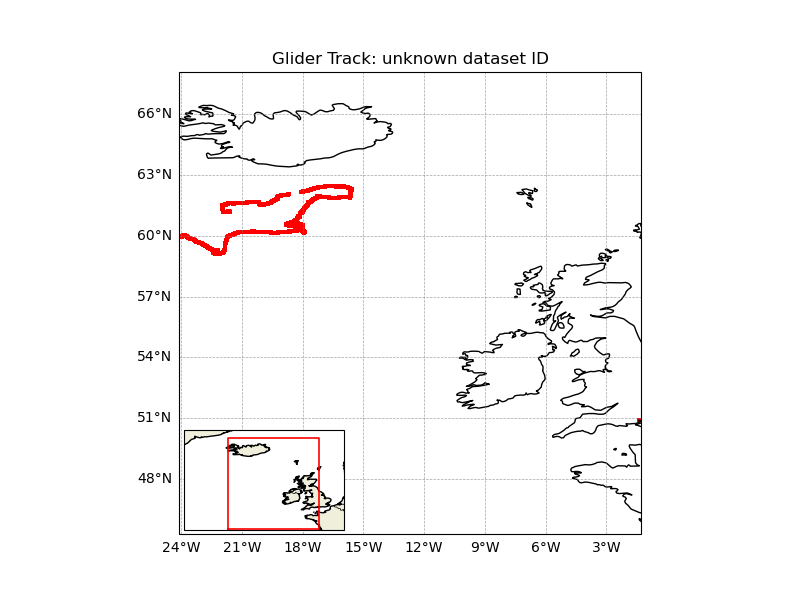

In [10]:
from IPython.display import Image
Image(f"{Pipe.pipeline["out_directory"]}geographic.png")

In [ ]:
#   Link to final PDF
path = f"{Pipe.pipeline['out_directory']}_build/latex/Report_Demo.pdf"
print(os.path.abspath(path))

/home/aaron-mau/Code/NOC-toolbox/mau/toolbox/examples/data/OG1/testing/_build/latex/Report_Demo.pdf
